<a href="https://colab.research.google.com/github/ians513/Analisis-de-datos/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto**
### Karen Oróstica, Alessandro Lavezzi, Nicolás Opazo, Ian Spikin.
## **Variabilidad hospitalaria en la práctica clínica**
### Pregunta principal:
### **¿Los hospitales ubicados en zonas de bajos recursos de la Región Metropolitana absorben sistemáticamente casos cardiovasculares de mayor severidad clínica?**

#### Preguntas auxiliares:
- ¿Pacientes con diagnósticos similares reciben procedimientos diferentes dependiendo
del hospital?
- ¿Existe variabilidad hospitalaria en la duración de hospitalización después de controlar
por severidad clínica?
- ¿Algunos hospitales presentan patrones sistemáticos de mayor intervención clínica?
- ¿Cómo se relacionan los lugares más vulnerables con los procedimientos hospitalarios y la duración de hospitalización?
- ¿Cómo se relacionan los lugares más vulnerables con la mortalidad de ciertos diagnósticos?


Datos:
- Egresos hospitalarios – GRD
- Ministerio de Salud de Chile / FONASA
- Índice de Prioridad Social


# Entorno de trabajo

In [ ]:
pip install lifelines

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import IPython.display as display
import sys
import json
import lifelines as lf
np.set_printoptions(threshold=sys.maxsize)
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = "/content/drive/MyDrive/Datos Colab/GRD_PUBLICO_2024.txt"

df = pd.read_csv(
    ruta,
    sep="|",
    encoding="latin-1",
    engine="python"
)

In [ ]:
df_copy=df.copy()

In [ ]:
ruta_cie9="/content/drive/MyDrive/Datos Colab/CIE-9 .xlsx"
df_procedimiento = pd.read_excel(ruta_cie9)

In [ ]:
ruta_cie10="/content/drive/MyDrive/Datos Colab/CIE-10.xlsx"
df_diagnostico = pd.read_excel(ruta_cie10)

In [ ]:
ruta_comunas="/content/drive/MyDrive/Datos Colab/comunas.geojson"

In [ ]:
ruta_hospitales="/content/drive/MyDrive/Datos Colab/establecimientos_20260331.csv"

Tabla maestra para manejar algunas variables:

In [ ]:
ruta_tabla_maestra="/content/drive/MyDrive/Datos Colab/Tablas maestras bases GRD .xlsx"
df_tabla_maestra_pabellon = pd.read_excel(ruta_tabla_maestra,sheet_name="Tipo de Pabellon")
df_tabla_maestra_ir_grd = pd.read_excel(ruta_tabla_maestra,sheet_name="IR - GRD")
df_tabla_maestra_severidad = pd.read_excel(ruta_tabla_maestra,sheet_name="Severidad GRD")
df_tabla_maestra_mortalidad= pd.read_excel(ruta_tabla_maestra,sheet_name="Mortalidad GRD")
df_tabla_maestra_hospitales= pd.read_excel(ruta_tabla_maestra,sheet_name="Hospitales")

# Análisis exploratorio

In [ ]:
df.head(3)

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHATRASLADO1,SERVICIOTRASLADO1,FECHATRASLADO2,SERVICIOTRASLADO2,FECHATRASLADO3,SERVICIOTRASLADO3,FECHATRASLADO4,SERVICIOTRASLADO4,FECHATRASLADO5,SERVICIOTRASLADO5,FECHATRASLADO6,SERVICIOTRASLADO6,FECHATRASLADO7,SERVICIOTRASLADO7,FECHATRASLADO8,SERVICIOTRASLADO8,FECHATRASLADO9,SERVICIOTRASLADO9,FECHAALTA,SERVICIOALTA,TIPOALTA,CONDICIONDEALTANEONATO1,PESORN1,SEXORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,SEXORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,SEXORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,1939-09-18,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,OFTALMOLOGÍA,CIRUGÍA MAYOR AMBULATORIA (CMA),2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H26.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.41,13.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71043147.0,NaN,2024-03-23,OFTALMOLOGÍA,71043147,1.0,022360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,1952-05-31,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,HEMATOLOGÍA,HOSPITALIZACIÓN,2024-09-26,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-02,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,FALLECIDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M31.1,R57.2,A41.5,A41.0,R41.8,R56.8,J96.09,N17.9,R41.0,D64.9,R16.1,N28.1,J90,E80.6,D70,D47.3,Z92.4,Z86.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.72,96.04,99.23,99.07,99.28,99.21,88.01,87.03,89.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78588090,NaN,041023,"5,8207",3,3,NaN
2,105101,77590791,HOMBRE,2012-07-17,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-26,PEDIATRÍA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K12.2,K02.9,E66.8,K01.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Columnas del DataFrame:

In [ ]:
#Mostrar los tipos de datos en el DataFrame
list(df.columns)

['COD_HOSPITAL',
 'ID_BENEFICIARIO',
 'SEXO',
 'FECHA_NACIMIENTO',
 'ETNIA',
 'PROVINCIA',
 'COMUNA',
 'NACIONALIDAD',
 'PREVISION',
 'SERVICIO_SALUD',
 'TIPO_PROCEDENCIA',
 'TIPO_INGRESO',
 'ESPECIALIDAD_MEDICA',
 'TIPO_ACTIVIDAD',
 'FECHA_INGRESO',
 'SERVICIOINGRESO',
 'FECHATRASLADO1',
 'SERVICIOTRASLADO1',
 'FECHATRASLADO2',
 'SERVICIOTRASLADO2',
 'FECHATRASLADO3',
 'SERVICIOTRASLADO3',
 'FECHATRASLADO4',
 'SERVICIOTRASLADO4',
 'FECHATRASLADO5',
 'SERVICIOTRASLADO5',
 'FECHATRASLADO6',
 'SERVICIOTRASLADO6',
 'FECHATRASLADO7',
 'SERVICIOTRASLADO7',
 'FECHATRASLADO8',
 'SERVICIOTRASLADO8',
 'FECHATRASLADO9',
 'SERVICIOTRASLADO9',
 'FECHAALTA',
 'SERVICIOALTA',
 'TIPOALTA',
 'CONDICIONDEALTANEONATO1',
 'PESORN1',
 'SEXORN1',
 'RN1ESTADO',
 'CONDICIONDEALTANEONATO2',
 'PESORN2',
 'SEXORN2',
 'RN2ESTADO',
 'CONDICIONDEALTANEONATO3',
 'PESORN3',
 'SEXORN3',
 'RN3ESTADO',
 'CONDICIONDEALTANEONATO4',
 'PESORN4',
 'SEXORN4',
 'RN4ESTADO',
 'DIAGNOSTICO1',
 'DIAGNOSTICO2',
 'DIAGNOSTICO3',
 

In [ ]:
print("Tipos de datos en el DataFrame:")
df.dtypes.value_counts()

Tipos de datos en el DataFrame:


,count
object,91
float64,36
int64,2


In [ ]:
df.describe()

,COD_HOSPITAL,CONDICIONDEALTANEONATO1,PESORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.085813e+06,0.0,119610.000000,97886.000000,0.0,1318.000000,1318.000000,0.0,15.000000,15.000000,0.0,0.0,0.0,0.0,482189.000000,408907.000000,284746.000000,236349.000000,196080.000000,163401.000000,137322.000000,99175.000000,85248.000000,63674.000000,55297.000000,48324.000000,42232.000000,36943.000000,32411.000000,28298.000000,24813.000000,21734.000000,18887.000000,16553.000000,6.182690e+05,0.0,1.085813e+06,655582.000000
mean,1.145584e+05,NaN,3166.208561,9.049905,NaN,2245.728376,8.585736,NaN,1667.533333,7.533333,NaN,NaN,NaN,NaN,89.522418,89.399217,89.042363,88.946015,88.711952,88.657424,88.485398,88.131194,87.952172,88.005153,87.697095,87.877795,87.774355,87.907581,87.922524,87.963993,87.974312,87.867828,88.050296,87.722094,8.187082e+07,NaN,8.332284e+07,1.388478
std,1.079607e+04,NaN,668.376257,1.067824,NaN,628.917866,1.752710,NaN,590.398760,2.559762,NaN,NaN,NaN,NaN,16.111245,16.032193,16.333756,16.376639,16.740058,16.824535,17.129954,17.737122,18.036492,18.032551,18.541461,18.333056,18.409138,18.300269,18.169013,18.164822,18.042320,18.212455,17.823259,18.519460,9.368715e+06,NaN,9.589261e+06,0.863487
min,1.011000e+05,NaN,100.000000,0.000000,NaN,150.000000,0.000000,NaN,100.000000,0.000000,NaN,NaN,NaN,NaN,0.090000,0.010000,0.010000,0.090000,0.010000,0.010000,0.090000,0.090000,0.010000,0.090000,0.090000,0.120000,0.120000,0.120000,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,NaN,6.698964e+07,0.000000
25%,1.091000e+05,NaN,2860.000000,9.000000,NaN,1905.000000,9.000000,NaN,1557.000000,7.500000,NaN,NaN,NaN,NaN,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,NaN,7.515274e+07,1.000000
50%,1.141010e+05,NaN,3250.000000,9.000000,NaN,2332.500000,9.000000,NaN,1755.000000,8.000000,NaN,NaN,NaN,NaN,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.390000,91.330000,91.330000,8.075476e+07,NaN,8.270110e+07,1.000000
75%,1.181050e+05,NaN,3590.000000,9.000000,NaN,2690.000000,9.000000,NaN,2050.000000,9.000000,NaN,NaN,NaN,NaN,99.190000,99.180000,97.690000,96.600000,96.590000,96.590000,96.590000,96.590000,96.570000,96.570000,96.570000,96.560000,96.550000,96.570000,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,NaN,9.167102e+07,1.000000
max,2.007170e+05,NaN,9730.000000,11.000000,NaN,3960.000000,10.000000,NaN,2315.000000,10.000000,NaN,NaN,NaN,NaN,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.990000,99.980000,99.980000,99.980000,99.980000,99.980000,99.980000,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,NaN,1.022985e+08,8.000000


# Variables que se eliminarán
En este caso nos interesa la comorbilidad, asi que los diagnósticos secundarios los conservaremos, para poder contemplar los distintos procedimientos clínicos.

Se eliminarán las variables que no otorgan información relevante, además de las que podrían sesgar el estudio:
- Traslado de servicio y fecha de traslado no aportan información, ya que la duración de la hospitalización se puede calcular con el ingreso y el alta.
- Los ID encriptados se eliminnrán, ya que su conservación podría sesgar el estudio a conclusiones intrahospitalarias.
- Las variables que relacionan neonatos se borrarán, ya que en el diagnóstico sale si el paciente llegó con parto múltiple.

In [ ]:
columnas_borrar=['ETNIA','NACIONALIDAD','CONDICIONDEALTANEONATO1','PESORN1','SEXORN1',
 'RN1ESTADO','CONDICIONDEALTANEONATO2','PESORN2','SEXORN2','RN2ESTADO',
 'CONDICIONDEALTANEONATO3','PESORN3','SEXORN3','RN3ESTADO','CONDICIONDEALTANEONATO4',
 'PESORN4','SEXORN4','RN4ESTADO','PREVISION','MEDICOINTERV1_ENCRIPTADO','MEDICOALTA_ENCRIPTADO','ID_BENEFICIARIO',
 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2','FECHATRASLADO3','SERVICIOTRASLADO3',
 'FECHATRASLADO4',  'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5',
 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7',
 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'COMUNA','PROVINCIA'
]
df = df.drop(columns=columnas_borrar)

In [ ]:
df

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,MUJER,1939-09-18,VIÑA DEL MAR QUILLOTA,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,OFTALMOLOGÍA,CIRUGÍA MAYOR AMBULATORIA (CMA),2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,DOMICILIO,H26.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.41,13.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23,OFTALMOLOGÍA,1.0,022360,"0,4384",0,0,NaN
1,107100,MUJER,1952-05-31,VIÑA DEL MAR QUILLOTA,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,HEMATOLOGÍA,HOSPITALIZACIÓN,2024-09-26,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,2024-10-02,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,FALLECIDO,M31.1,R57.2,A41.5,A41.0,R41.8,R56.8,J96.09,N17.9,R41.0,D64.9,R16.1,N28.1,J90,E80.6,D70,D47.3,Z92.4,Z86.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.72,96.04,99.23,99.07,99.28,99.21,88.01,87.03,89.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,041023,"5,8207",3,3,NaN
2,105101,HOMBRE,2012-07-17,COQUIMBO,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,2024-01-22,PEDIATRÍA,2024-01-26,PEDIATRÍA,DOMICILIO,K12.2,K02.9,E66.8,K01.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,23.19,99.21,99.29,99.23,99.26,93.96,87.11,89.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-26,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",2.0,034141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,HOMBRE,1952-11-03,METROPOLITANO ORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,UROLOGÍA,HOSPITALIZACIÓN,2024-04-08,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-04-14,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,C61,K63.1,K66.0,E66.9,Z53.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.33,54.59,45.91,99.21,99.29,93.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-08,UROLOGÍA,1.0,061203,"3,5647",3,3,NaN
4,118100,MUJER,1994-02-28,CONCEPCIÓN,"APS URGENCIA (SAPU, SUR, SUC)",URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,2024-09-24,CIRUGÍA,2024-09-26,CIRUGÍA,DOMICILIO,K35.8,K42.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.01,89.04,88.76,99.29,99.21,99.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Filtro con Dataset de Hospitales:

In [ ]:
with open(ruta_comunas, 'r') as f:
    data = json.load(f)

df_comunas = pd.json_normalize(data['features'])
# GeoJSON properties are typically nested under 'properties'
# We need to extract the properties dictionary from each feature
de_comunas = pd.json_normalize(data['features'], sep='_')
df_comunas = pd.DataFrame([f['properties'] for f in data['features']])
df_comunas.head()

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia
0,48,170038.6241,16,8,6204,6,9.685774e+08,206184.2716,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro
1,29,125730.1047,15,8,6102,6,4.157446e+08,151911.5768,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal
2,30,63026.0844,15,8,6103,6,1.448565e+08,76355.3261,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal
3,31,89840.9035,15,8,6104,6,3.256572e+08,108874.6231,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal
4,78,122626.4932,23,11,9121,9,6.990727e+08,156680.4106,Región de La Araucanía,Cholchol,Cautín


In [ ]:
df_hospitales=pd.read_csv(ruta_hospitales, sep=';')

In [ ]:
servicios_y_tal=["Servicio de Salud Metropolitano Central","Servicio de Salud Metropolitano Oriente",
                 "Servicio de Salud Metropolitano Norte","Servicio de Salud Metropolitano Sur Oriente",
                 "Servicio de Salud Metropolitano Sur","Servicio de Salud Metropolitano Occidente"]
#filtrar por servicio
df_hospitales = df_hospitales[df_hospitales['SeremiSaludGlosa_ServicioDeSaludGlosa'].isin(servicios_y_tal)]
df_hospitales

,EstablecimientoCodigo,EstablecimientoGlosa,EstablecimientoCodigoAntiguo,EstablecimientoCodigoMadreAntiguo,EstablecimientoCodigoMadreNuevo,RegionCodigo,RegionGlosa,SeremiSaludCodigo_ServicioDeSaludCodigo,SeremiSaludGlosa_ServicioDeSaludGlosa,TipoPertenenciaEstabGlosa,TipoEstablecimientoGlosa,AmbitoFuncionamiento,Certificacion,DependenciaAdministrativa,NivelAtencionEstabglosa,ComunaCodigo,ComunaGlosa,TipoViaGlosa,Numero,NombreVia,TelefonoMovil_TelefonoFijo,FechaInicioFuncionamientoEstab,TieneServicioUrgencia,TipoUrgencia,ClasificacionTipoSapu,Latitud,Longitud,TipoSistemaSaludGlosa,EstadoFuncionamiento,NivelComplejidadEstabGlosa,TipoAtencionEstabGlosa,FechaIncorporacion,FechaCierre
541,200188,Centro de Especialidades Odontológicas Leng,12-905,NaN,NaN,13,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,Clínica Dental,Establecimiento de Salud,No Aplica,Municipal,Primario,13123,Providencia,Avenida,1261,Eliodoro Yáñez,222352510,29-01-2015,NO,No Aplica,No Aplica,-33.433596,-70.617745,Público,Vigente en Operación Habitual,Mediana Complejidad,Atención Abierta-Ambulatoria,NaN,NaN
663,200080,Centro Odontológico La Reina,12-901,NaN,NaN,13,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,Clínica Dental,Establecimiento de Salud,No Aplica,Municipal,Primario,13113,La Reina,Calle,25,Cordillera,224816184,05-02-2013,NO,No Aplica,No Aplica,-33.452528,-70.534632,Público,Vigente en Operación Habitual,Mediana Complejidad,Atención Abierta-Ambulatoria,NaN,NaN
887,112323,Centro Odontológico Macul,12-323,NaN,NaN,13,Región Metropolitana de Santiago,12.0,Servicio de Salud Metropolitano Oriente,Perteneciente al Sistema Nacional de Servicios...,Clínica Dental,Establecimiento de Salud,No Aplica,Municipal,Primario,13118,Macul,Calle,4345,Arturo Prat,225739600,NaN,NO,No Aplica,No Aplica,-33.493489,-70.614616,Público,Vigente en Operación Habitual,Mediana Complejidad,Atención Abierta-Ambulatoria,NaN,NaN
2300,110393,Centro de Salud Familiar Villa Alhué,10-393,NaN,NaN,13,Región Metropolitana de Santiago,10.0,Servicio de Salud Metropolitano Occidente,Perteneciente al Sistema Nacional de Servicios...,Centro de Salud Familiar (CESFAM),Establecimiento de Salud,Centro de Salud Familiar,Municipal,Primario,13502,Alhué,Calle,440,21 de Mayo,226125201,NaN,NO,No Aplica,No Aplica,-34.032480,-71.100080,Público,Vigente en Operación Habitual,Baja Complejidad,Atención Abierta-Ambulatoria,NaN,NaN
2301,200878,SUR Villa Alhué,10-934,10-393,110393.0,13,Región Metropolitana de Santiago,10.0,Servicio de Salud Metropolitano Occidente,Perteneciente al Sistema Nacional de Servicios...,Servicio de Urgencia Rural (SUR),Establecimiento de Salud,No Aplica,Municipal,Primario,13502,Alhué,Calle,NaN,21 de Mayo,225760105,NaN,SI,Urgencia Ambulatoria (SUR),No Aplica,-34.032484,-71.100076,Público,Vigente en Operación Habitual,Baja Complejidad,Atención Abierta-Ambulatoria,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524,202205,CESFAM Cerro Colorado,NaN,NaN,NaN,13,Región Metropolitana de Santiago,10.0,Servicio de Salud Metropolitano Occidente,Perteneciente al Sistema Nacional de Servicios...,Centro de Salud Familiar (CESFAM),Establecimiento de Salud,Centro de Salud Familiar,Municipal,Primario,13128,Renca,Calle,5266,José Manuel Balmaceda 5266,NaN,03-09-2025,No,No Aplica,No Aplica,-33.402166,-70.727564,Público,Vigente en operación habitual,Baja Complejidad,Atención Abierta-Ambulatoria,30-10-2025,NaN
5539,202221,SAR Dr. Gustavo Molina,NaN,10-352,110352.0,13,Región Metropolitana de Santiago,10.0,Servicio de Salud Metropolitano Occidente,Perteneciente al Sistema Nacional de Servicios...,Servicio de Atención Primaria de Urgencia de A...,Establecimiento de Salud,No Aplica,Municipal,Primario,13124,Pudahuel,Calle,8759,Laguna Sur,227495991,01-01-2026,SI,Urgenc

In [ ]:
codigos_metropolitanos=df_hospitales["EstablecimientoCodigo"].values #extraigo los codigos de hospitales en reg metropolitana
df=df[df["COD_HOSPITAL"].isin(codigos_metropolitanos)]

In [ ]:
df.head()

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
3,112100,HOMBRE,1952-11-03,METROPOLITANO ORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,UROLOGÍA,HOSPITALIZACIÓN,2024-04-08,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-04-14,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,C61,K63.1,K66.0,E66.9,Z53.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.33,54.59,45.91,99.21,99.29,93.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-08,UROLOGÍA,1.0,061203,"3,5647",3,3,NaN
10,112100,MUJER,1930-03-28,METROPOLITANO ORIENTE,OTROS HOSPITALES DE LA RED,URGENCIA,TRAUMATOLOGÍA Y ORTOPEDIA,HOSPITALIZACIÓN,2024-08-09,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,2024-08-17,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,DOMICILIO,S72.10,W01.04,I10,G20,F31.9,Z59.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.15,93.01,93.12,93.18,99.19,99.29,88.26,89.52,90.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-13,TRAUMATOLOGÍA Y ORTOPEDIA,1.0,081202,"1,4691",2,2,"HOSPITAL DR. LUIS TISNÉ B. (SANTIAGO, PEÑALOLÉN)"
11,112100,HOMBRE,1958-08-25,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,2024-09-27,AREA QUIRÚRGICA,2024-10-16,AREA QUIRÚRGICA,DOMICILIO,T29.2,X12.84,T31.0,E11.9,I10,I87.2,E66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.63,86.22,99.21,99.29,93.12,93.18,91.53,91.56,91.59,89.52,99.21,93.17,93.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DESCONOCIDA,CIRUGÍA GENERAL,1.0,091202,"2,0678",2,2,NaN
12,112100,MUJER,1996-06-13,LIBERTADOR B. O HIGGINS,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",URGENCIA,HEMATO-ONCOLOGÍA PEDIÁTRICA,HOSPITALIZACIÓN,2024-09-29,AREA MEDICA ADULTO CUIDADOS MEDIOS,2024-10-04,AREA MEDICA ADULTO CUIDADOS MEDIOS,DOMICILIO,C91.0,C79.3,G93.5,D69.6,R51,I10,E03.9,Z94.8,Z51.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.23,99.05,99.29,89.13,87.03,87.41,88.01,88.38,90.53,90.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174103,"4,5426",3,3,NaN
13,112100,HOMBRE,2000-02-18,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,MEDICINA INTERNA,HOSPITALIZACIÓN,2024-10-16,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,2024-11-15,UNIDAD DE TRATAMIENTO INTERMEDIO MEDICINA ADULTO,DOMICILIO,K72.0,K72.1,G61.0,E83.4,K70.1,N17.9,D68.9,K85.9,B25.9,K76.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
df['ESPECIALIDAD_MEDICA'].value_counts().index
filtro_especialidad=['CARDIOLOGÍA','CIRUGÍA VASCULAR PERIFÉRICA','CIRUGÍA CARDIOVASCULAR','CARDIOLOGÍA PEDIÁTRICA']
df_especialidad=df[df['ESPECIALIDAD_MEDICA'].isin(filtro_especialidad)]
#df_especialidad

In [ ]:
#df['ESPECIALIDADINTERVENCION'].value_counts().index
filtro_intervencion=['CIRUGÍA VASCULAR PERIFÉRICA','CIRUGÍA CARDIOVASCULAR','CARDIOLOGÍA','CARDIOLOGÍA PEDIÁTRICA']
df_intervencion=df[df['ESPECIALIDADINTERVENCION'].isin(filtro_intervencion)]
#df_intervencion

In [ ]:
#CUANDO NO COINCIDE LA ESPECIALIDAD DEL MEDICO CON LA DE INTERVENCION, SEGUN EL MEDICO
df_especialidad[~df_especialidad['ESPECIALIDADINTERVENCION'].isin(filtro_intervencion)]

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
143,114101,MUJER,1952-09-10,METROPOLITANO SURORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-11-13,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,2024-11-13,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,DOMICILIO,I20.9,I10,I49.5,E11.9,E03.9,I25.2,E78.5,C50.8,Z90.1,Z92.6,Z95.0,Z92.2,Z80.0,Z80.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,051152,"1,0746",2,2,NaN
355,114101,MUJER,1959-05-22,METROPOLITANO SURORIENTE,OTROS HOSPITALES DE LA RED,PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-07-24,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,2024-07-24,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,I21.4,I25.1,I10,Z92.2,Z88.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,051151,"0,8838",1,1,HOSPITAL CLINICO METROPOLITANO LA FLORIDA DRA....
356,114101,MUJER,1932-08-11,METROPOLITANO SURORIENTE,OTROS HOSPITALES DE LA RED,PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-07-24,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,2024-07-24,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,I21.4,I25.1,I48.9,I50.0,E11.9,E03.9,J44.8,Z92.2,Z86.0,D37.4,Z92.1,Z90.4,Z58.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00.66,00.42,00.47,36.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,051402,"1,8183",2,2,HOSPITAL CLINICO METROPOLITANO LA FLORIDA DRA....
363,114101,HOMBRE,1955-08-09,METROPOLITANO SURORIENTE,"APS URGENCIA (SAPU, SUR, SUC)",URGENCIA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-11-30,DERIVACIÓN MÉDICO QUIRÚRGICO,2024-12-01,DERIVACIÓN MÉDICO QUIRÚRGICO,DOMICILIO,J44.0,I50.0,J96.09,J81,I10,E11.9,I51.7,I25.2,Z95.4,Z92.2,Z86.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.90,93.96,87.41,89.52,99.29,99.19,93.18,90.59,90.39,89.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,044173,"0,8551",3,3,NaN
447,112100,MUJER,1929-12-28,METROPOLITANO ORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA VASCULAR PERIFÉRICA,HOSPITALIZACIÓN,2024-03-26,AREA QUIRÚRGICA,2024-03-28,AREA QUIRÚRGICA,DOMICILIO,I77.1,I10,I50.9,L89.0,E11.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
df=df_especialidad.merge(df_intervencion)
df

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,113100,HOMBRE,1964-04-19,METROPOLITANO SUR,"APS URGENCIA (SAPU, SUR, SUC)",URGENCIA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-09-23,UNIDAD DE CUIDADOS INTENSIVOS CARDIOLOGÍA,2024-09-28,MEDICINA,DOMICILIO,I21.1,N17.9,E11.9,I10,E78.5,B24,Q60.2,F17.2,Z88.8,Z92.2,Z92.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00.66,00.41,00.46,36.07,87.44,88.72,99.19,89.54,93.18,93.12,89.44,99.17,99.18,99.29,94.23,89.52,90.59,89.66,89.59,89.39,91.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARDIOLOGÍA,4.0,051403,"2,484",3,3,NaN
1,112102,MUJER,2012-12-29,CONCEPCIÓN,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CARDIOLOGÍA PEDIÁTRICA,HOSPITALIZACIÓN,2024-07-18,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,2024-07-19,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,DOMICILIO,Q23.8,Q24.8,Q20.1,Q22.0,Q25.5,Q26.8,Q27.8,I77.8,I82.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.79,88.50,88.42,88.43,88.44,88.63,00.67,93.96,87.49,99.19,99.21,99.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARDIOLOGÍA PEDIÁTRICA,8.0,051203,"3,267",3,2,NaN
2,114101,HOMBRE,1961-12-23,METROPOLITANO SURORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-04-18,DERIVACIÓN MÉDICO QUIRÚRGICO,2024-04-18,DERIVACIÓN MÉDICO QUIRÚRGICO,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,Z45.0,I44.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,CIRUGÍA CARDIOVASCULAR,2.0,051303,"2,7376",3,3,NaN
3,112102,MUJER,2024-03-16,CONCEPCIÓN,OTROS HOSPITALES RED NACIONAL,URGENCIA,CIRUGÍA CARDIOVASCULAR,HOSPITALIZACIÓN,2024-06-05,UNIDAD DE CUIDADOS INTENSIVOS CARDIVASCULAR,2024-06-26,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,DOMICILIO,Q24.5,I42.0,I51.8,R13,F19.4,T81.4,Y83.8,E46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.59,39.56,37.11,34.72,96.72,93.90,93.96,93.94,39.61,39.62,39.63,39.64,87.49,0.17,99.19,88.72,96.60,96.35,99.15,99.23,99.26,99.29,99.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-07,CIRUGÍA CARDIOVASCULAR,8.0,051063,"4,1777",3,2,HOSPITAL CLÍNICO REGIONAL DR. GUILLERMO GRANT ...
4,111100,MUJER,1988-07-06,METROPOLITANO CENTRAL,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CIRUGÍA VASCULAR PERIFÉRICA,HOSPITALIZACIÓN,2024-04-15,CIRUGÍA,2024-04-18,CIRUGÍA,DOMICILIO,T82.8,Y83.2,N18.5,Z99.2,I10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## Traducción de payasadas:

In [ ]:
print("DataFrame de procedimientos:")
display.display(df_procedimiento.head())
print("DataFrame de diagnósticos:")
display.display(df_diagnostico.head())
print("DataFrame de tabla maestra - Tipo de Pabellon:")
display.display(df_tabla_maestra_pabellon.head())
print("DataFrame de tabla maestra - IR - GRD:")
display.display(df_tabla_maestra_ir_grd.head())
print("DataFrame de tabla maestra - Severidad GRD:")
display.display(df_tabla_maestra_severidad.head())
print("DataFrame de tabla maestra - Mortalidad GRD:")
display.display(df_tabla_maestra_mortalidad.head())
print("DataFrame de tabla maestra - Hospitales:")
display.display(df_tabla_maestra_hospitales.head())

DataFrame de procedimientos:


,Código,Descripción,Categoría,Sección,Capítulo
0,0.00,PROCEDIMIENTO E INTERVENCION NCOC,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
1,0.00,ULTRASONIDO TERAPEUTICO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
2,0.01,ULTRASONIDO TERAPEUTICO.VASO CABEZA Y CUELLO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
3,0.02,ULTRASONIDO TERAPEUTICO.CORAZON,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...
4,0.03,ULTRASONIDO TERAPEUTICO.VASO PERIFERICO,"00 PROCEDIMIENTOS E INTERVENCIONES, NO CLASIFI...",00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...,00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO...


DataFrame de diagnósticos:


,Versión,Código,Descripción,Categoría,Sección,Capítulo
0,CIE-v2013,A00,Cólera,A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
1,CIE-v2013,A00.0,"Cólera debido a Vibrio cholerae O1, biotipo ch...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
2,CIE-v2013,A00.1,"Cólera debido a Vibrio cholerae O1, biotipo El...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
3,CIE-v2013,A00.9,"Cólera, no especificado",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
4,CIE-v2013,A01,Fiebres tifoidea y paratifoidea,A01 FIEBRES TIFOIDEA Y PARATIFOIDEA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...


DataFrame de tabla maestra - Tipo de Pabellon:


...

,Severidad,Unnamed: 1
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


DataFrame de tabla maestra - Mortalidad GRD:


,Mortalidad,Unnamed: 1
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


DataFrame de tabla maestra - Hospitales:


,HOSPITALES,Unnamed: 1
0,101100,Hospital Dr. Juan Noé Crevanni (Arica)
1,101203,Clínica Hebe
2,101212,Clínica San Agustín
3,101213,Clínica San José
4,101215,Complejo Penitenciario


In [ ]:
#df['IR_29301_COD_GRD'] = df['IR_29301_COD_GRD'].astype(str).str.strip()
df_tabla_maestra_ir_grd['IR- GRD'] = df_tabla_maestra_ir_grd['IR- GRD'].astype(str).str.strip()
df['IR_29301_COD_GRD'] = pd.to_numeric(df['IR_29301_COD_GRD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_ir_grd,left_on="IR_29301_COD_GRD",right_on="IR- GRD",how="left")
df.drop(columns=['IR- GRD','IR_29301_COD_GRD'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'GRD'})
#df

In [ ]:
df['IR_29301_SEVERIDAD'] = df['IR_29301_SEVERIDAD'].astype(str).str.strip()
df_tabla_maestra_severidad['Severidad'] = df_tabla_maestra_severidad['Severidad'].astype(str).str.strip()
df['IR_29301_SEVERIDAD'] = pd.to_numeric(df['IR_29301_SEVERIDAD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_severidad,left_on="IR_29301_SEVERIDAD",right_on="Severidad",how="left")
df.drop(columns=['IR_29301_SEVERIDAD','Severidad'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'SEVERIDAD'})
#df

In [ ]:
df['IR_29301_MORTALIDAD'] = df['IR_29301_MORTALIDAD'].astype(str).str.strip()
df_tabla_maestra_mortalidad['Mortalidad'] = df_tabla_maestra_mortalidad['Mortalidad'].astype(str).str.strip()
df['IR_29301_MORTALIDAD'] = pd.to_numeric(df['IR_29301_MORTALIDAD'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_mortalidad,left_on="IR_29301_MORTALIDAD",right_on="Mortalidad",how="left")
df.drop(columns=['IR_29301_MORTALIDAD','Mortalidad'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'MORTALIDAD'})
#df

In [ ]:
df['COD_HOSPITAL'] = df['COD_HOSPITAL'].astype(str).str.strip()
df_tabla_maestra_hospitales['HOSPITALES'] = df_tabla_maestra_hospitales['HOSPITALES'].astype(str).str.strip()
df['COD_HOSPITAL'] = pd.to_numeric(df['COD_HOSPITAL'], errors='coerce').fillna(-1).astype(int).astype(str)
df=pd.merge(df,df_tabla_maestra_hospitales,left_on="COD_HOSPITAL",right_on="HOSPITALES",how="left")
df.drop(columns=['COD_HOSPITAL','HOSPITALES'], inplace=True)
df = df.rename(columns={'Unnamed: 1': 'HOSPITAL'})
#df

In [ ]:
df.head()

,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHAALTA,SERVICIOALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,USOSPABELLON,IR_29301_PESO,HOSPPROCEDENCIA,GRD,SEVERIDAD,MORTALIDAD,HOSPITAL
0,HOMBRE,1964-04-19,METROPOLITANO SUR,"APS URGENCIA (SAPU, SUR, SUC)",URGENCIA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-09-23,UNIDAD DE CUIDADOS INTENSIVOS CARDIOLOGÍA,2024-09-28,MEDICINA,DOMICILIO,I21.1,N17.9,E11.9,I10,E78.5,B24,Q60.2,F17.2,Z88.8,Z92.2,Z92.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00.66,00.41,00.46,36.07,87.44,88.72,99.19,89.54,93.18,93.12,89.44,99.17,99.18,99.29,94.23,89.52,90.59,89.66,89.59,89.39,91.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARDIOLOGÍA,4.0,"2,484",NaN,PH PROCEDIMIENTOS CARDIOVASCULARES PERCUTÁNEOS...,Mayor,Mayor,"Hospital Barros Luco Trudeau (Santiago, San Mi..."
1,MUJER,2012-12-29,CONCEPCIÓN,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CARDIOLOGÍA PEDIÁTRICA,HOSPITALIZACIÓN,2024-07-18,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,2024-07-19,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,DOMICILIO,Q23.8,Q24.8,Q20.1,Q22.0,Q25.5,Q26.8,Q27.8,I77.8,I82.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.79,88.50,88.42,88.43,88.44,88.63,00.67,93.96,87.49,99.19,99.21,99.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARDIOLOGÍA PEDIÁTRICA,8.0,"3,267",NaN,PH OTROS PROCEDIMIENTOS SOBRE APARATO CIRCULAT...,Mayor,Moderada,Hospital de Niños Dr. Luis Calvo Mackenna (San...
2,HOMBRE,1961-12-23,METROPOLITANO SURORIENTE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2024-04-18,DERIVACIÓN MÉDICO QUIRÚRGICO,2024-04-18,DERIVACIÓN MÉDICO QUIRÚRGICO,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,Z45.0,I44.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,CIRUGÍA CARDIOVASCULAR,2.0,"2,7376",NaN,PH SUSTITUCIÓN DE GENERADOR DE DESFIBRILADOR Y...,Mayor,Mayor,Complejo Hospitalario Dr. Sótero del Río (Sant...
3,MUJER,2024-03-16,CONCEPCIÓN,OTROS HOSPITALES RED NACIONAL,URGENCIA,CIRUGÍA CARDIOVASCULAR,HOSPITALIZACIÓN,2024-06-05,UNIDAD DE CUIDADOS INTENSIVOS CARDIVASCULAR,2024-06-26,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,DOMICILIO,Q24.5,I42.0,I51.8,R13,F19.4,T81.4,Y83.8,E46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.59,39.56,37.11,34.72,96.72,93.90,93.96,93.94,39.61,39.62,39.63,39.64,87.49,0.17,99.19,88.72,96.60,96.35,99.15,99.23,99.26,99.29,99.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-07,CIRUGÍA CARDIOVASCULAR,8.0,"4,1777",HOSPITAL CLÍNICO REGIONAL DR. GUILLERMO GRANT ...,PH OTROS PROCEDIMIENTOS CAR

In [ ]:
# Normalizamos el maestro de procedimientos
df_procedimiento['Código'] = df_procedimiento['Código'].astype(str).str.strip()
dict_proc = df_procedimiento.set_index('Código')['Descripción'].to_dict()

# Normalizamos el maestro de diagnósticos (por si acaso)
df_diagnostico['Código'] = df_diagnostico['Código'].astype(str).str.strip()
dict_diag = df_diagnostico.set_index('Código')['Descripción'].to_dict()


In [ ]:
cols_diag = [f'DIAGNOSTICO{i}' for i in range(1, 35 + 1)]
cols_proc = [f'PROCEDIMIENTO{i}' for i in range(1, 30 + 1)]

In [ ]:
# 1. Definimos una función de normalización para asegurar ceros a la izquierda
def normalizar_codigo_cie(val):
    if pd.isna(val) or str(val).lower() == 'nan':
        return None
    s = str(val).strip()
    # Si es un número que perdió el cero inicial (ej: '0.1' -> '00.1')
    if '.' in s:
        partes = s.split('.')
        partes[0] = partes[0].zfill(2)
        return f"{partes[0]}.{partes[1]}"
    else:
        return s.zfill(2)

# 2. Normalizamos las llaves de los diccionarios maestros
df_procedimiento['Código'] = df_procedimiento['Código'].apply(normalizar_codigo_cie)
dict_proc = df_procedimiento.set_index('Código')['Descripción'].to_dict()

df_diagnostico['Código'] = df_diagnostico['Código'].astype(str).str.strip().unique()
dict_diag = df_diagnostico.set_index('Código')['Descripción'].to_dict()

# 3. Mapeo de Diagnósticos
for col in cols_diag:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().map(dict_diag)

# 4. Mapeo de Procedimientos usando los códigos originales de df_copy para evitar los NaN actuales
for col in cols_proc:
    if col in df.columns:
        # Recuperamos el valor original, lo normalizamos y luego lo mapeamos
        df[col] = df_copy.loc[df.index, col].apply(normalizar_codigo_cie).map(dict_proc)

print("Mapeo finalizado. Se aplicó normalización de ceros a la izquierda para códigos de procedimientos.")

Mapeo finalizado. Se aplicó normalización de ceros a la izquierda para códigos de procedimientos.


# A4A44A4A4A4A

# Visualizaciones iniciales de apoyo

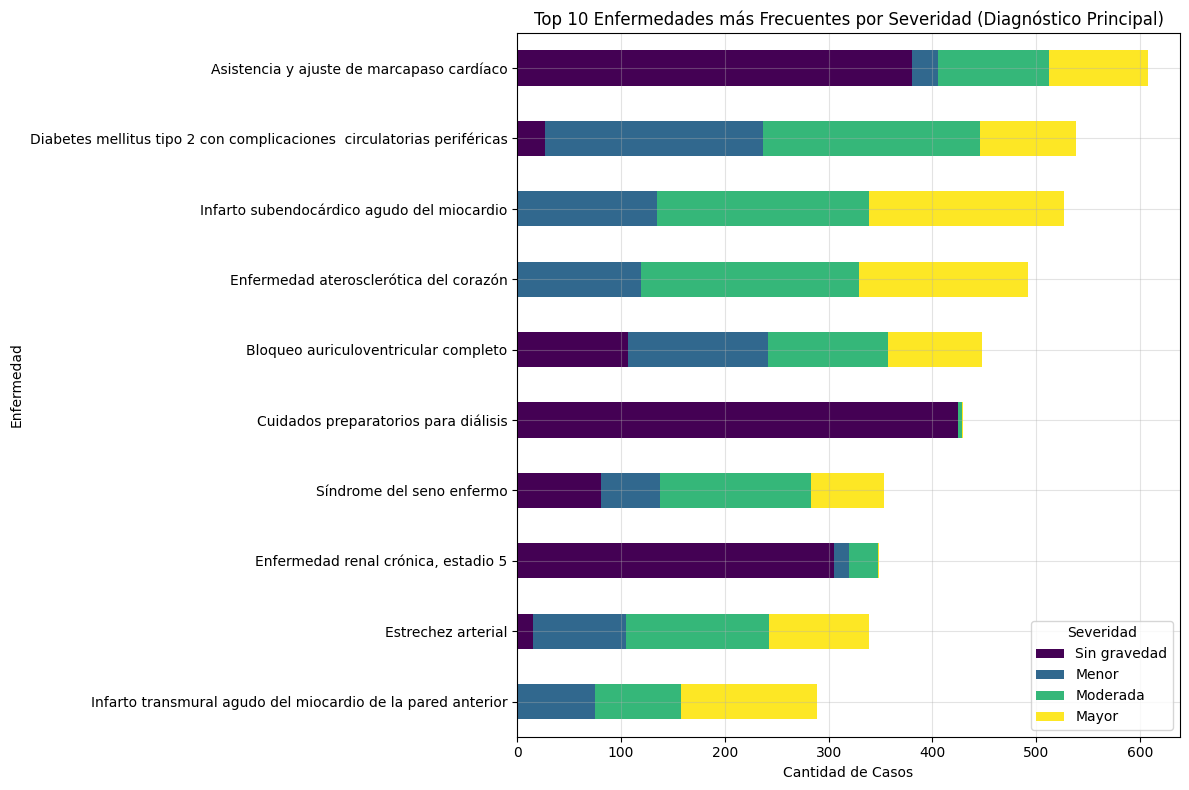

In [ ]:
# @title
top_diagnoses = (
    df['DIAGNOSTICO1']
    .dropna()
    .astype(str)
    .str.strip()
)

top_diagnoses = top_diagnoses[top_diagnoses != ""]
top_diagnoses = top_diagnoses[top_diagnoses.str.lower() != "nan"]
top_diagnoses = top_diagnoses.value_counts().head(10).index

# Filter the DataFrame to include only these top diagnoses
df_top_diagnoses = df[df['DIAGNOSTICO1'].isin(top_diagnoses)].copy()

# Group by DIAGNOSTICO1 and SEVERIDAD, then count
df_diag_severity = df_top_diagnoses.groupby(['DIAGNOSTICO1', 'SEVERIDAD']).size().unstack(fill_value=0)

# Ensure severity order for plotting
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
# Reindex to ensure all severity columns exist and are in order
df_diag_severity = df_diag_severity.reindex(columns=orden_severidad, fill_value=0)

# Calculate total cases for each diagnosis and sort
df_diag_severity['Total'] = df_diag_severity.sum(axis=1)
df_diag_severity = df_diag_severity.sort_values(by='Total', ascending=True).drop(columns='Total')

# Plotting as a horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
df_diag_severity.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

plt.title('Top 10 Enfermedades más Frecuentes por Severidad (Diagnóstico Principal)')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Enfermedad')
plt.legend(title='Severidad')
plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

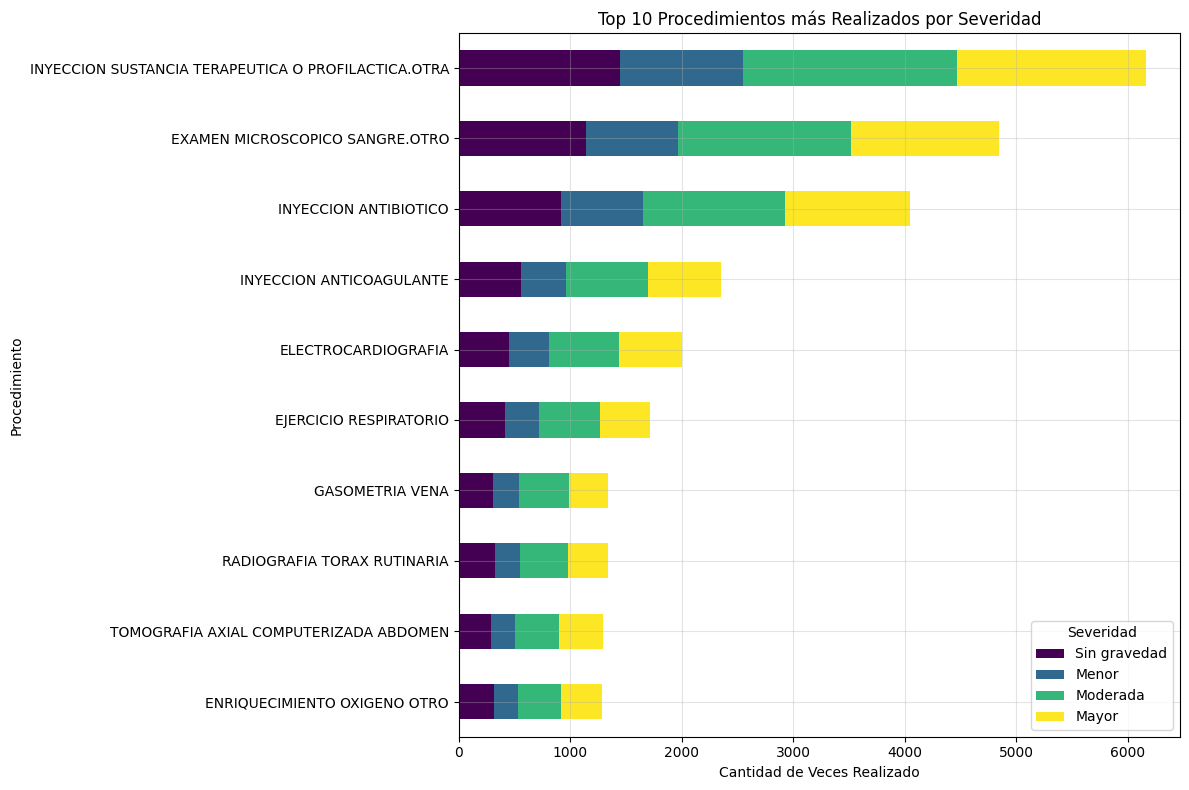

In [ ]:
# @title
# Columnas de procedimientos (ajusta el rango si tienes más o menos)
cols_proc = [f'PROCEDIMIENTO{i}' for i in range(1, 30 + 1)]

# Filtrar solo las columnas que existen en el df
cols_proc_existentes = [col for col in cols_proc if col in df.columns]

# Create a temporary DataFrame for all procedures and their severities
procedure_severity_list = []
for col in cols_proc_existentes:
    # Only include non-null procedures and their corresponding severity
    temp_df = df[[col, 'SEVERIDAD']].dropna(subset=[col]).copy()
    temp_df = temp_df[temp_df[col].astype(str).str.strip() != ""]
    temp_df = temp_df[temp_df[col].astype(str).str.lower() != "nan"]
    temp_df.columns = ['PROCEDIMIENTO', 'SEVERIDAD']
    procedure_severity_list.append(temp_df)

df_procedures_long = pd.concat(procedure_severity_list, ignore_index=True)

# Get the top 10 most frequent procedures
top_procedures = df_procedures_long['PROCEDIMIENTO'].value_counts().head(10).index

# Filter the long format DataFrame to include only these top procedures
df_top_procedures_filtered = df_procedures_long[df_procedures_long['PROCEDIMIENTO'].isin(top_procedures)]

# Group by PROCEDURE and SEVERIDAD, then count
df_proc_severity = df_top_procedures_filtered.groupby(['PROCEDIMIENTO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Ensure severity order for plotting
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
# Reindex to ensure all severity columns exist and are in order
df_proc_severity = df_proc_severity.reindex(columns=orden_severidad, fill_value=0)

# Calculate total cases for each procedure and sort
df_proc_severity['Total'] = df_proc_severity.sum(axis=1)
df_proc_severity = df_proc_severity.sort_values(by='Total', ascending=True).drop(columns='Total')

# Plotting as a horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
df_proc_severity.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

plt.title('Top 10 Procedimientos más Realizados por Severidad')
plt.xlabel('Cantidad de Veces Realizado')
plt.ylabel('Procedimiento')
plt.legend(title='Severidad')
plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

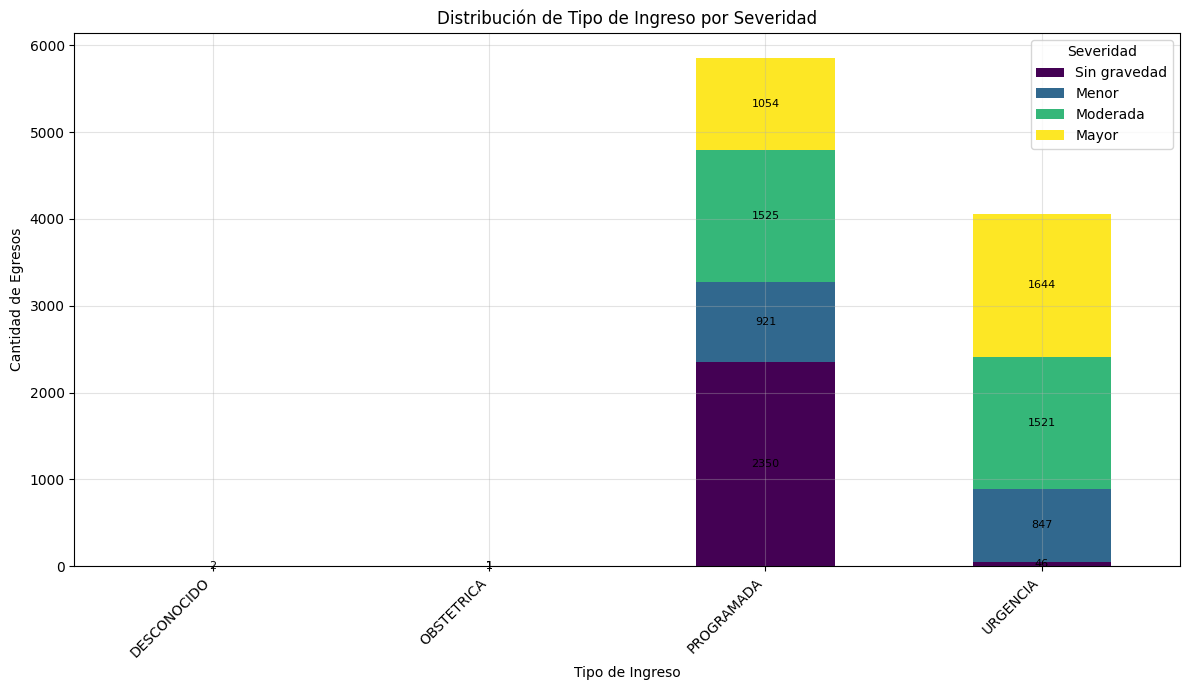

In [ ]:
# @title
plt.figure(figsize=(10, 7))

# Agrupar por TIPO_INGRESO y SEVERIDAD
df_grouped = df.groupby(['TIPO_INGRESO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto para el apilamiento
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_grouped = df_grouped[orden_severidad]

# Crear el gráfico de barras apiladas
ax = df_grouped.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis', ax=plt.gca())

plt.title('Distribución de Tipo de Ingreso por Severidad')
plt.xlabel('Tipo de Ingreso')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        # Solo si el valor es mayor que 0, para evitar etiquetas en segmentos vacíos
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{int(height)}',
                    ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

### Tipo de Actividad Hospitalaria por Severidad

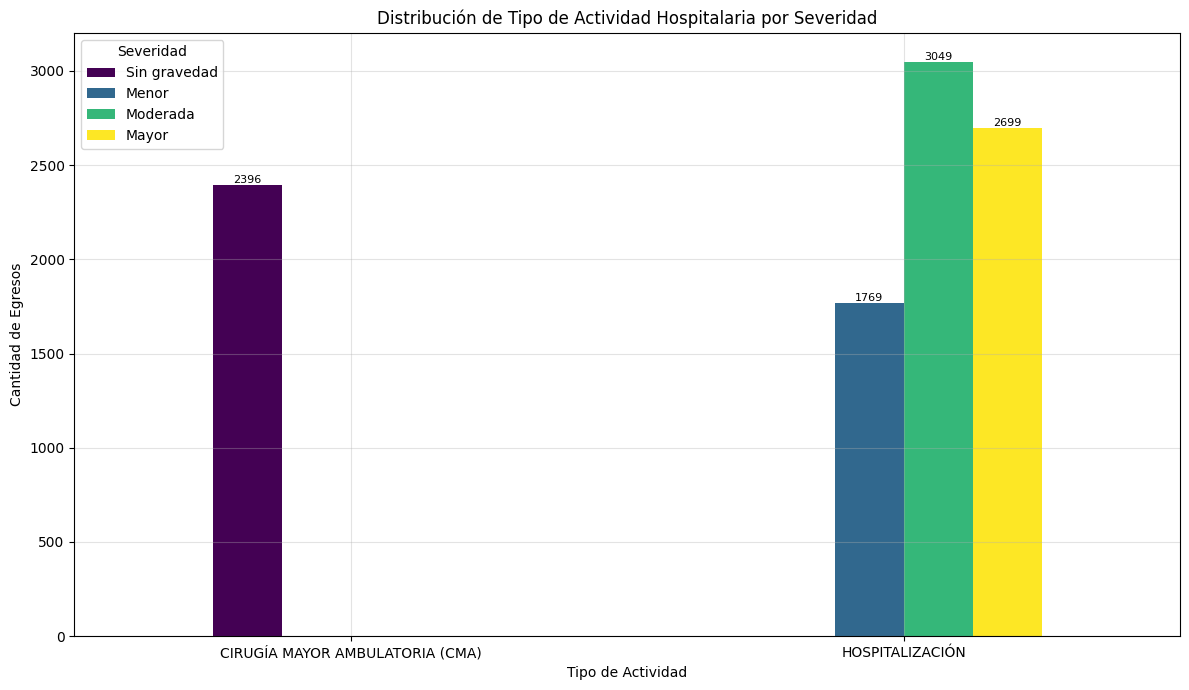

In [ ]:
# @title
plt.figure(figsize=(12, 7))

# Agrupar por TIPO_ACTIVIDAD y SEVERIDAD
df_activity_severity = df.groupby(['TIPO_ACTIVIDAD', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_activity_severity = df_activity_severity[orden_severidad]

# Crear el gráfico de barras agrupadas
ax = df_activity_severity.plot(kind='bar', figsize=(12, 7), cmap='viridis', ax=plt.gca())

plt.title('Distribución de Tipo de Actividad Hospitalaria por Severidad')
plt.xlabel('Tipo de Actividad')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height, f'{int(height)}',
                    ha='center', va='bottom', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

# Análisis de Severidad por Sexo en la Región Metropolitana

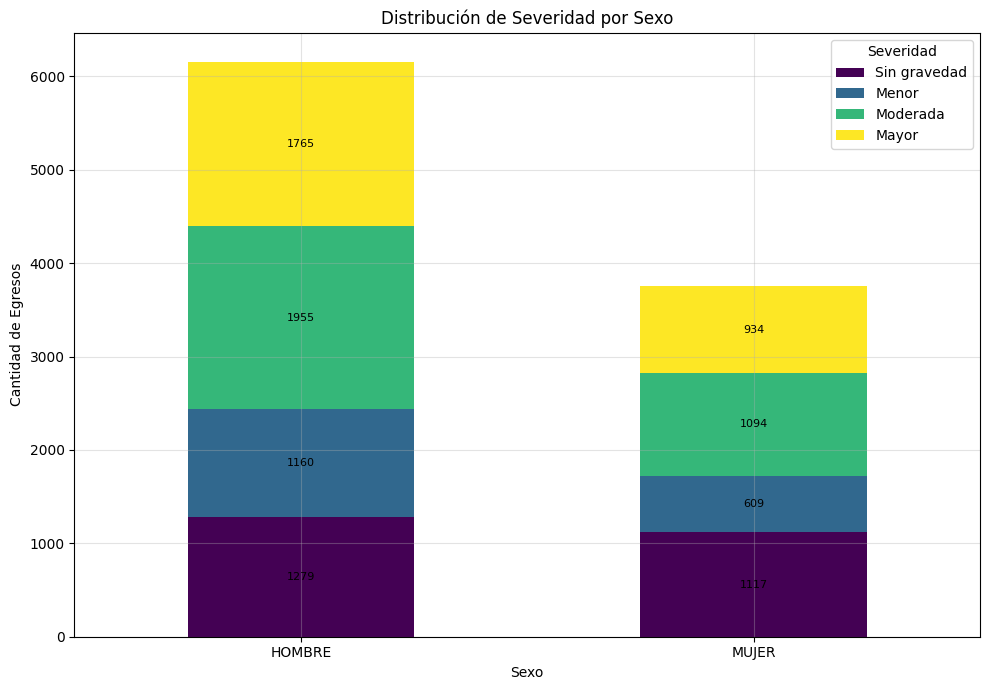

In [ ]:
# @title
# Agrupar por SEXO y SEVERIDAD
df_sex_severity = df.groupby(['SEXO', 'SEVERIDAD']).size().unstack(fill_value=0)

# Asegurarse de que la severidad esté en el orden correcto para el apilamiento
orden_severidad = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor']
df_sex_severity = df_sex_severity.reindex(columns=orden_severidad, fill_value=0)

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(10, 7))
df_sex_severity.plot(kind='bar', stacked=True, cmap='viridis', ax=ax)

plt.title('Distribución de Severidad por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Egresos')
plt.xticks(rotation=0)
plt.legend(title='Severidad')

# Añadir los números a cada barra
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        x, y = patch.get_xy()
        # Solo si el valor es mayor que 0, para evitar etiquetas en segmentos vacíos
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{int(height)}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.grid(alpha=0.35)
plt.show()

In [ ]:
df["HOSPITAL"].value_counts()

,count
HOSPITAL,
"Hospital San Juan de Dios (Santiago, Santiago)",1730
"Hospital Barros Luco Trudeau (Santiago, San Miguel)",1421
"Complejo Hospitalario San José (Santiago, Independencia)",1365
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",1077
"Hospital Del Salvador (Santiago, Providencia)",1042
Instituto Nacional de Enfermedades Respiratorias y Cirugía Torácica,1018
"Hospital Clínico San Borja-Arriarán (Santiago, Santiago)",809
"Hospital Clínico de Niños Dr. Roberto del Río (Santiago, Independencia)",452
Hospital Clínico Metropolitano El Carmen Doctor Luis Valentín Ferrada,396


### Cálculo del Índice de Casuística (CMI) por Hospital

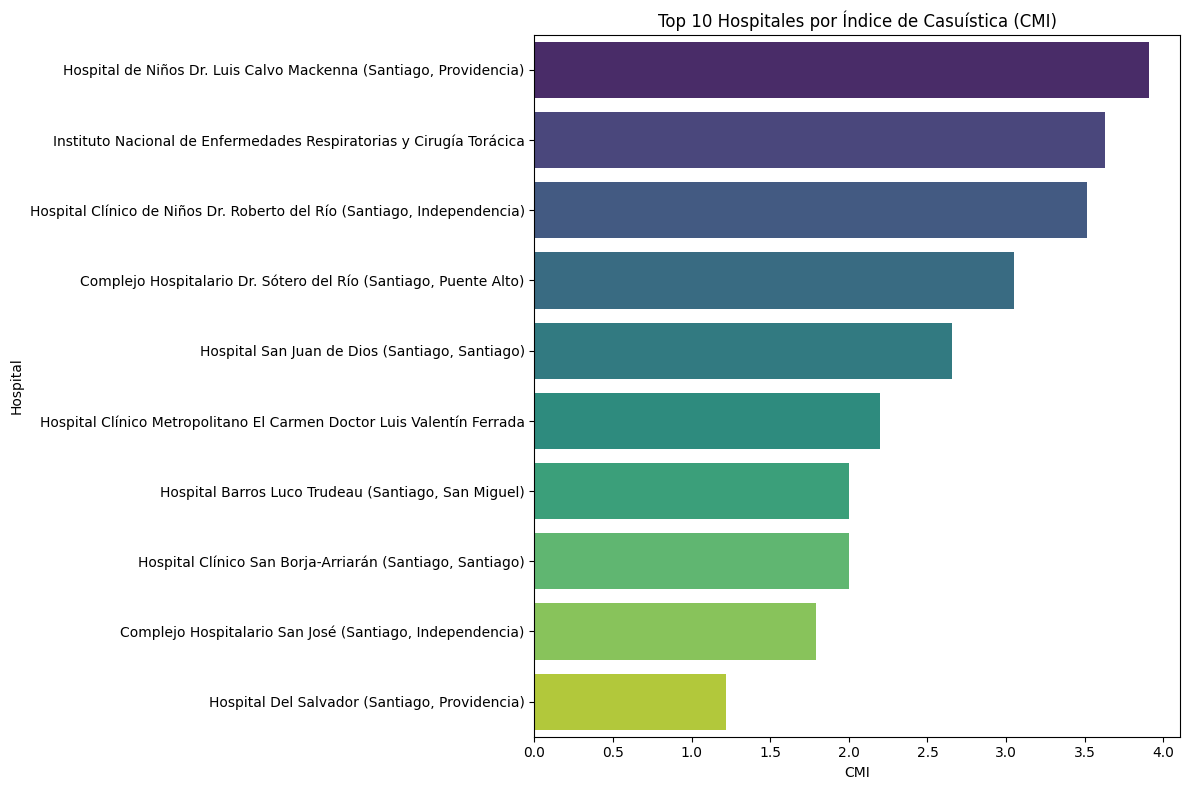

In [ ]:
# @title

if df['IR_29301_PESO'].astype(str).str.contains(',').any():
  df['IR_29301_PESO'] = df['IR_29301_PESO'].str.replace(',', '.', regex=False)
  df['IR_29301_PESO'] = pd.to_numeric(df['IR_29301_PESO'], errors='coerce')
cmi_por_hospital = df.groupby('HOSPITAL')['IR_29301_PESO'].mean().sort_values(ascending=False)

#print("Índice de Casuística (CMI) por Hospital (Top 10):")
#print(cmi_por_hospital.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x=cmi_por_hospital.head(10).values, y=cmi_por_hospital.head(10).index, palette='viridis', hue=cmi_por_hospital.head(10).index)
plt.title('Top 10 Hospitales por Índice de Casuística (CMI)')
plt.xlabel('CMI')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

## Índices:

In [ ]:
#PARA VARIABLE DE DIAS DE ESTANCIA
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])
df['FECHAALTA'] = pd.to_datetime(df['FECHAALTA'])
df['DIAS_ESTANCIA'] = (df['FECHAALTA'] - df['FECHA_INGRESO']).dt.days
#df.head()

In [ ]:
#Indice de mortalidad por paciente
#SI VIVO Y COLEANDO= 0
#SI MUERTO = 1
df['MORTALIDAD_BINARIA'] = (df['TIPOALTA'] == 'FALLECIDO').astype(int)
#df.head()

# Tablas de contingenias

Tabla de contingencia entre Diagnostico y sexo

In [ ]:
tabla = pd.crosstab(
    df['DIAGNOSTICO1'],
    df['SEXO']
)
tabla

SEXO,HOMBRE,MUJER
DIAGNOSTICO1,,
"Absceso cutáneo, furúnculo y carbunco de miembro",4,1
Absceso del mediastino,1,0
Aneurisma cardíaco,1,1
Aneurisma de arteria coronaria,1,0
"Aneurisma de la aorta abdominal, sin mención de ruptura",56,15
...,...,...
Várices en otros sitios especificados,0,3
Várices pélvicas,0,2
Úlcera de decúbito estadio IV,2,1


Tabla de contingencia entre GRD y Severidad

In [ ]:
tabla2 = pd.crosstab(
    df['GRD'],
    df['SEVERIDAD']
)
tabla2

SEVERIDAD,Mayor,Menor,Moderada,Sin gravedad
GRD,,,,
"INAGRUPABLE, PACIENTE AMBULATORIO CON PROCED. DE HOSPITALIZACIÓN",0,0,0,10
MA MOTIVO DE LA VISITA: INSUFICIENCIA CARDIACA Y OTRAS PATOLOGÍAS CARDIACAS,0,0,0,4
MA MOTIVO DE LA VISITA: OTRO ESTADO CRÓNICO COMPLEJO,0,0,0,2
MH ATEROSCLEROSIS W/CC,0,0,1,0
MH CELULITIS W/CC,0,0,3,0
...,...,...,...,...
PH SUSTITUCIÓN DE GENERADOR DE DESFIBRILADOR Y MARCAPASOS CARDIACO W/MCC,119,0,0,0
PH TRASPLANTE CARDIACO Y/O PULMONAR W/MCC,1,0,0,0
PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA,0,1,0,0


Tabla de contingencia entre Tipo ingreso y Tipo alta

In [ ]:
tabla3 = pd.crosstab(
    df['TIPO_INGRESO'],
    df['TIPOALTA']
)
tabla3

TIPOALTA,ALTA VOLUNTARIA,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,DOMICILIO,FALLECIDO,FUGA DEL PACIENTE,HOSPITALIZACIÓN DOMICILIARIA
TIPO_INGRESO,,,,,,,,,
DESCONOCIDO,0,0,0,0,0,2,0,0,0
OBSTETRICA,0,0,0,0,0,3,0,0,0
PROGRAMADA,11,5,1,102,104,5542,55,0,30
URGENCIA,40,9,8,101,47,3440,190,5,218


Tabla de contingencia entre Especialidad medica y mortalidad

In [ ]:
tabla4 = pd.crosstab(
    df['ESPECIALIDAD_MEDICA'],
    df['MORTALIDAD']
)
tabla4

MORTALIDAD,Mayor,Menor,Moderada,Sin gravedad
ESPECIALIDAD_MEDICA,,,,
CARDIOLOGÍA,1064,820,1072,982
CARDIOLOGÍA PEDIÁTRICA,51,207,104,0
CIRUGÍA CARDIOVASCULAR,746,515,907,6
CIRUGÍA VASCULAR PERIFÉRICA,563,749,719,1408


Tabla de contingencia entre Diagnostico y Mortalidad

In [ ]:
tabla_pct = pd.crosstab(
    df['DIAGNOSTICO1'],
    df['MORTALIDAD'],
    normalize='index'
) * 100
tabla_pct

MORTALIDAD,Mayor,Menor,Moderada,Sin gravedad
DIAGNOSTICO1,,,,
"Absceso cutáneo, furúnculo y carbunco de miembro",0.000000,40.000000,60.000000,0.000000
Absceso del mediastino,0.000000,100.000000,0.000000,0.000000
Aneurisma cardíaco,50.000000,0.000000,50.000000,0.000000
Aneurisma de arteria coronaria,100.000000,0.000000,0.000000,0.000000
"Aneurisma de la aorta abdominal, sin mención de ruptura",33.802817,40.845070,23.943662,1.408451
...,...,...,...,...
Várices en otros sitios especificados,0.000000,33.333333,0.000000,66.666667
Várices pélvicas,0.000000,50.000000,0.000000,50.000000
Úlcera de decúbito estadio IV,33.333333,0.000000,66.666667,0.000000


Tabla de contingencia entre Diagnostico y sexo

In [ ]:
tabla5 = pd.crosstab(
    df['DIAGNOSTICO1'],
    df['SEXO'],
    margins=True
)
tabla5

SEXO,HOMBRE,MUJER,All
DIAGNOSTICO1,,,
"Absceso cutáneo, furúnculo y carbunco de miembro",4,1,5
Absceso del mediastino,1,0,1
Aneurisma cardíaco,1,1,2
Aneurisma de arteria coronaria,1,0,1
"Aneurisma de la aorta abdominal, sin mención de ruptura",56,15,71
...,...,...,...
Várices pélvicas,0,2,2
Úlcera de decúbito estadio IV,2,1,3
Úlcera de decúbito y area de presión no especificadas,2,0,2


In [ ]:
tabla6 = pd.crosstab(
    df['SERVICIOINGRESO'],
    df['SERVICIOALTA']
)
tabla6

SERVICIOALTA,AGUDOS CIRUGÍA,AGUDOS MEDICINA,AREA MEDICA ADULTO CUIDADOS MEDIOS,AREA MEDICO-QUIRURGICO CUIDADOS BASICOS,AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,AREA MÉDICA,AREA QUIRÚRGICA,CIRUGÍA,CIRUGÍA DE PARTES BLANDAS INFANTIL,CIRUGÍA INFANTIL,DERIVACIÓN MÉDICO QUIRÚRGICO,DESCONOCIDO,GERIATRÍA,GINECOLOGÍA,HOSPITAL DE DÍA MÉDICO,HOSPITAL DE DÍA QUIRÚRGICO,INFECCIOSOS INFANTIL,LACTANTES,MEDICINA,NEUROCIRUGÍA ADULTO,NEUROLOGÍA ADULTO,OFTALMOLOGÍA,OTORRINOLARINGOLOGÍA,PEDIATRÍA,PENSIONADO ADULTO,SEGUNDA INFANCIA,TRAUMATOLOGÍA Y ORTOPEDIA,UNIDAD DE AGUDOS MEDICO QUIRÚRGICOS,UNIDAD DE AGUDOS NEUROLOGÍA,UNIDAD DE CUIDADOS INTENSIVOS (UCI) (INDIFERENCIADO),UNIDAD DE CUIDADOS INTENSIVOS ADULTO,UNIDAD DE CUIDADOS INTENSIVOS CARDIOLOGÍA,UNIDAD DE CUIDADOS INTENSIVOS CARDIVASCULAR,UNIDAD DE CUIDADOS INTENSIVOS NEONATOLOGÍA,UNIDAD DE CUIDADOS INTENSIVOS PEDIATRÍA,UNIDAD DE CUIDADOS INTENSIVOS QUEMADOS,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL Y CMA),UNIDAD DE TRATAMIENTO INTERMEDIO (UTI) (INDIFERENCIADO) ADULTO,UNIDAD DE TRATAMIENTO INTERMEDIO CARDIOVASCULAR,UNIDAD DE TRATAMIENTO INTERMEDIO CIRUGÍA ADULTO,UNIDAD DE TRATAMIENTO INTERMEDIO CORONARIO,UNIDAD DE TRATAMIENTO INTERMEDIO MEDICINA ADULTO,UNIDAD DE TRATAMIENTO INTERMEDIO NEONATOLOGÍA,UNIDAD DE TRATAMIENTO INTERMEDIO PEDIATRÍA,UNIDAD DE TRATAMIENTOS INTERMEDIOS MEDICINA,UNIDAD EMERGENCIA (INDIFERENCIADO),UNIDAD EMERGENCIA ADULTOS,UROLOGÍA
SERVICIOINGRESO,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AGUDOS CIRUGÍA,45,1,0,0,0,0,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,1,1,0,0,0,1,0,1,0,1,4,1,0,0,0,0,0,0
AGUDOS MEDICINA,1,35,0,0,0,0,0,1,0,0,6,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,0,1,0,0,0
AREA MEDICA ADULTO CUIDADOS MEDIOS,0,0,23,0,34,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,3,1,0,0,0,0,0,0,0,0
AREA MEDICO-QUIRURGICO CUIDADOS BASICOS,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AREA MEDICO-QUIRURGICO CUIDADOS MEDIOS,0,0,2,0,666,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,4,0,0,0,0,0,0,26,1,0,2,0,0,0,0,0,0
AREA MÉDICA,0,0,0,0,1,4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
AREA QUIRÚRGICA,0,0,0,0,20,0,258,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0
CIRUGÍA,24,4,0,0,0,0,0,1255,0,0,0,0,4,0,0,0,0,0,19,0,0,0,0,0,0,0,1,0,0,3,4,1,0,0,0,2,0,16,0,8,27,3,0,0,9,0,0,2
CIRUGÍA DE PARTES BLANDAS INFANTIL,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
tabla7 = pd.crosstab(
    df['HOSPITAL'],
    df['TIPOALTA']
)
tabla7

TIPOALTA,ALTA VOLUNTARIA,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,DOMICILIO,FALLECIDO,FUGA DEL PACIENTE,HOSPITALIZACIÓN DOMICILIARIA
HOSPITAL,,,,,,,,,
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",1,0,2,3,113,889,37,0,32
"Complejo Hospitalario San José (Santiago, Independencia)",15,3,0,21,2,1224,52,3,45
"Hospital Barros Luco Trudeau (Santiago, San Miguel)",16,3,4,18,2,1280,21,1,76
Hospital Clínico Metropolitano El Carmen Doctor Luis Valentín Ferrada,1,0,0,0,3,327,8,0,57
Hospital Clínico Metropolitano La Florida Dra. Eloisa Díaz Inzunza,0,0,0,0,0,119,0,0,0
"Hospital Clínico San Borja-Arriarán (Santiago, Santiago)",3,2,0,2,1,788,10,0,3
"Hospital Clínico de Niños Dr. Roberto del Río (Santiago, Independencia)",0,2,0,66,1,367,16,0,0
"Hospital Del Salvador (Santiago, Providencia)",6,1,2,1,9,1012,9,0,2
"Hospital Dr. Félix Bulnes Cerda (Santiago, Quinta Normal)",0,0,0,0,0,115,0,0,1


# Pregunta de hipotesis


Pregunta 1

| **Componente**                      | **Descripción**                                                                                                                                                                                                      |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Pregunta de investigación**          | ¿Existe una diferencia significativa entre la estancia hospitalaria según rango socioeconómico?**
| **Hipótesis estadísticas**          | **H0:** No existe una diferencia significativa en la estancia hospitalaria según rango socioeconómico.
**Hipótesis estadísticas**   |**H1:** Sí existe una diferencia significativa en la estancia hospitalaria según rango socioeconómico.        |
| **Comparación a realizar**          | Se analizará la estancia hospitalaria en relación con el rango socioeconómico, utilizando como referencia la media de días de hospitalización (**ALOS**) y su categorización mediante el índice de prioridad social. |
| **Prueba estadística seleccionada** | Se aplicará la prueba de **Kruskal-Wallis**, adecuada para comparar más de dos grupos cuando la variable dependiente no sigue una distribución normal.                                                               |
| **Fundamento metodológico**         | La estancia hospitalaria suele presentar asimetría y no normalidad, lo que está descrito en la literatura y puede relacionarse con el fenómeno de “cama social”.                                                     |
| **Evaluaciones adicionales**        | Se podrán incorporar gráficos de distribución y **QQplot** para explorar el comportamiento de la variable antes del análisis inferencial.                                                                            |


Pregunta 2

| **Componente**                      | **Descripción**                                                                                                                                                                                                                                                                                                               |
| ----------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Pregunta de investigación**       | ¿Los hospitales en zonas de bajos recursos absorben casos de mayor severidad clínica?                                                                                                                                                                                                                                         |
| **Hipótesis estadísticas**          | **H₀:** No existen diferencias significativas en la severidad clínica de los pacientes entre hospitales ubicados en zonas de distinto nivel socioeconómico. <br><br> **H₁:** Existen diferencias significativas en la severidad clínica de los pacientes entre hospitales ubicados en zonas de distinto nivel socioeconómico. |
| **Comparación a realizar**          | Se comparará el nivel socioeconómico de las zonas con la severidad clínica de los pacientes atendidos en hospitales de la Región Metropolitana. Además, se considerarán variables como duración de hospitalización, mortalidad y cantidad de procedimientos.                                                                  |
| **Variables de análisis**           | Severidad clínica, duración de hospitalización, mortalidad, cantidad de procedimientos, nivel de vulnerabilidad territorial.                                                                                                                                                                                                  |
| **Prueba estadística seleccionada** | Se aplicará la prueba de **Chi-cuadrado** para evaluar la asociación entre variables categóricas.                                                                                                                                                                                                                             |
| **Fundamento metodológico**         | La prueba de Chi-cuadrado es adecuada para analizar la relación entre variables categóricas, especialmente cuando los datos son binarios o categorizados y no requieren supuestos de normalidad.                                                                                                                              |
| **Evaluaciones adicionales**        | Se podrán complementar los análisis con tablas de contingencia, medidas de asociación y visualizaciones para facilitar la interpretación de los resultados.                                                                                                                                                                   |
